In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer


In [ ]:
df = pd.read_csv('/home/calorie_efficiency_dataset.csv')

In [ ]:
df

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,55,5881,81,1500,4.06,1.91,25.66,5,0.322,0.101,70.0,110.8,2,0.387,Low Efficiency
999996,53,3303,41,1500,6.65,1.58,26.21,1,0.200,0.329,67.4,111.3,1,1.393,Low Efficiency
999997,28,8553,62,1500,5.33,3.86,20.70,4,0.426,0.339,61.4,119.0,1,0.515,Low Efficiency
999998,34,6936,52,1500,8.52,1.58,21.95,7,0.251,0.332,64.9,107.0,2,0.595,Low Efficiency


In [ ]:
df = pd.read_csv('/home/calorie_efficiency_dataset.csv',usecols=['age','workouts_per_week','heart_rate_avg','efficiency_score','calorie_efficiency'])

In [ ]:
df

,age,workouts_per_week,heart_rate_avg,efficiency_score,calorie_efficiency
0,51,3,102.0,0.603,Low Efficiency
1,60,6,121.2,0.958,Low Efficiency
2,59,2,120.4,0.987,Low Efficiency
3,39,1,114.8,0.711,Low Efficiency
4,22,2,116.2,0.551,Low Efficiency
...,...,...,...,...,...
999995,55,5,110.8,0.387,Low Efficiency
999996,53,1,111.3,1.393,Low Efficiency
999997,28,4,119.0,0.515,Low Efficiency
999998,34,7,107.0,0.595,Low Efficiency


In [ ]:
df.head()

,age,workouts_per_week,heart_rate_avg,efficiency_score,calorie_efficiency
0,51,3,102.0,0.603,Low Efficiency
1,60,6,121.2,0.958,Low Efficiency
2,59,2,120.4,0.987,Low Efficiency
3,39,1,114.8,0.711,Low Efficiency
4,22,2,116.2,0.551,Low Efficiency


In [ ]:
df.isnull().sum()

,0
age,0
workouts_per_week,0
heart_rate_avg,0
efficiency_score,0
calorie_efficiency,0


In [ ]:
X = df.iloc[:,0:4]
y = df.iloc[:,4:]

In [ ]:
X

,age,workouts_per_week,heart_rate_avg,efficiency_score
0,51,3,102.0,0.603
1,60,6,121.2,0.958
2,59,2,120.4,0.987
3,39,1,114.8,0.711
4,22,2,116.2,0.551
...,...,...,...,...
999995,55,5,110.8,0.387
999996,53,1,111.3,1.393
999997,28,4,119.0,0.515
999998,34,7,107.0,0.595


In [ ]:
y

,calorie_efficiency
0,Low Efficiency
1,Low Efficiency
2,Low Efficiency
3,Low Efficiency
4,Low Efficiency
...,...
999995,Low Efficiency
999996,Low Efficiency
999997,Low Efficiency
999998,Low Efficiency


In [ ]:
y['calorie_efficiency'].value_counts().sum()

np.int64(1000000)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
y.loc[:, 'calorie_efficiency'] = enc.fit_transform(y[['calorie_efficiency']])

In [ ]:
y['calorie_efficiency']

,calorie_efficiency
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
999995,1.0
999996,1.0
999997,1.0
999998,1.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=40)

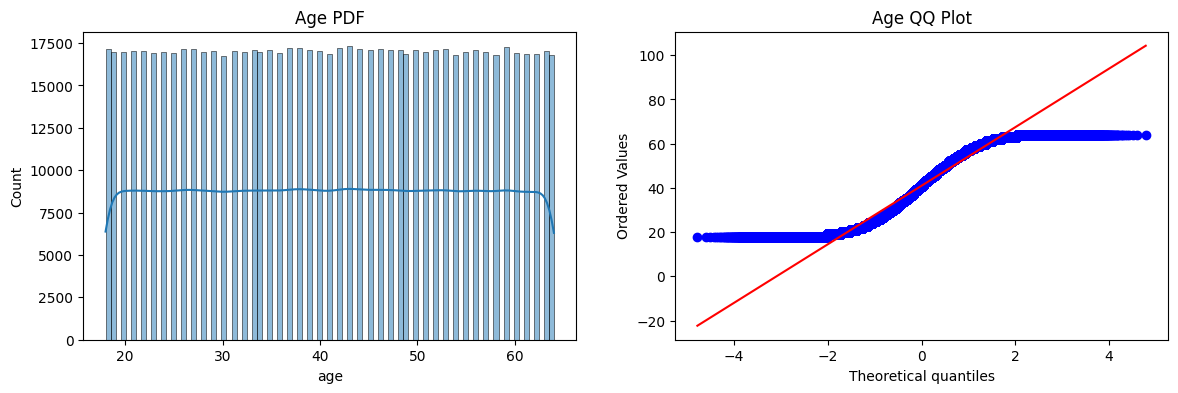

In [ ]:
plt.figure(figsize=(14,4))

# Histogram + KDE (Replacement of distplot)
plt.subplot(121)
sns.histplot(X_train['age'], kde=True)
plt.title('Age PDF')

# QQ Plot
plt.subplot(122)
stats.probplot(X_train['age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

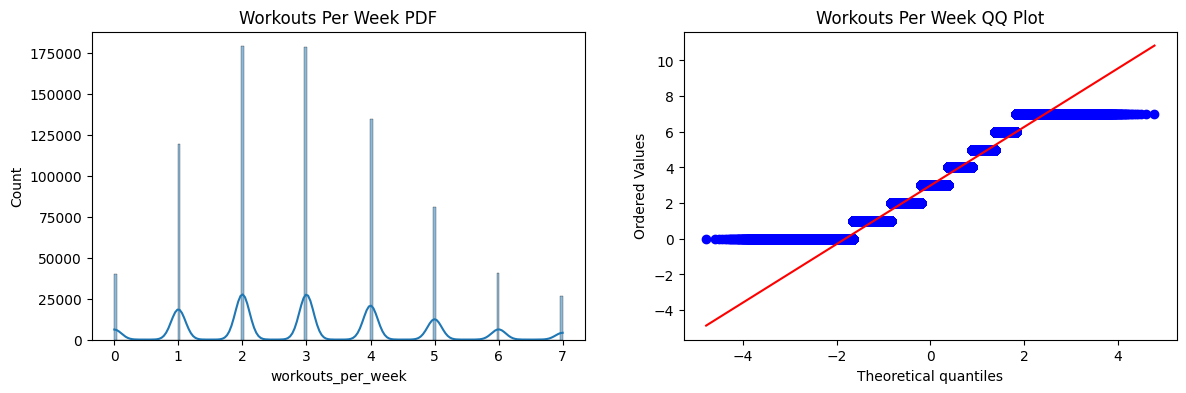

In [ ]:
plt.figure(figsize=(14,4))

# 📊 Histogram + KDE
plt.subplot(121)
sns.histplot(X_train['workouts_per_week'], kde=True)
plt.title('Workouts Per Week PDF')

# 📈 QQ Plot
plt.subplot(122)
stats.probplot(X_train['workouts_per_week'], dist="norm", plot=plt)
plt.title('Workouts Per Week QQ Plot')

plt.show()

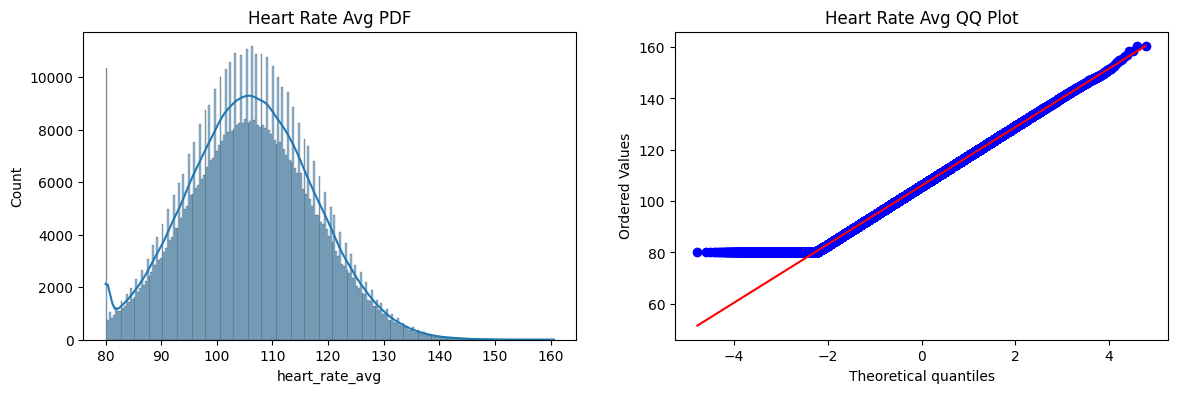

In [ ]:
plt.figure(figsize=(14,4))

# 📊 Histogram + KDE
plt.subplot(121)
sns.histplot(X_train['heart_rate_avg'], kde=True)
plt.title('Heart Rate Avg PDF')

# 📈 QQ Plot
plt.subplot(122)
stats.probplot(X_train['heart_rate_avg'], dist="norm", plot=plt)
plt.title('Heart Rate Avg QQ Plot')

plt.show()

In [ ]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:

alg = DecisionTreeClassifier()

In [ ]:
alg.fit(X_train,y_train)
y_pred1 = alg.predict(X_test)
print(accuracy_score(y_test,y_pred1))

0.885135


In [ ]:
trf = FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_function_transformer.py:387: RuntimeWarning: invalid value encountered in log1p
  return func(X, **(kw_args if kw_args else {}))


In [ ]:
# Models
alg2 = DecisionTreeClassifier()

# Train
alg2.fit(X_train_transformed, y_train)

# Predict
y_pred1 = alg2.predict(X_test_transformed)

# Accuracy
print(accuracy_score(y_test, y_pred1))


0.888775
